# Regression Analysis
Simple Linear Regression

In [25]:
import pandas as pd  
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [26]:
dataset = pd.read_csv(r"Salary_dataset.csv")
dataset.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [27]:
print(dataset.info())

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes
None


In [28]:
print(dataset.isnull().sum())


Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64


In [29]:
if "Unnamed: 0" in dataset.columns:
    dataset.drop("Unnamed: 0", axis=1,inplace=True)

In [30]:
print(dataset.describe())

       YearsExperience         Salary
count        30.000000      30.000000
mean          5.413333   76004.000000
std           2.837888   27414.429785
min           1.200000   37732.000000
25%           3.300000   56721.750000
50%           4.800000   65238.000000
75%           7.800000  100545.750000
max          10.600000  122392.000000


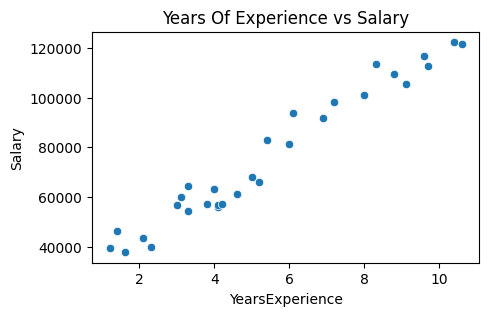

In [31]:
plt.figure(figsize=(5,3))
sns.scatterplot(x="YearsExperience",
                y="Salary",
                data= dataset)
plt.title("Years Of Experience vs Salary")
plt.show()

In [41]:
x = dataset[["YearsExperience"]]
y = dataset["Salary"]

In [42]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [44]:
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9423.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.438e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [45]:
print("Slope (Coffecient):",model.coef_[0])
print("Intercept:",model.intercept_)

Slope (Coffecient): 9423.81532303098
Intercept: 24380.20147947369


In [46]:
y_pred = model.predict(x_test)

In [47]:
print("\n Model Performance")
print("R Square score :",r2_score(y_test,y_pred))
print("MAE  :", mean_absolute_error(y_test,y_pred))
print("MSE  :", mean_squared_error(y_test,y_pred))
print("RMSE  :", mean_squared_error(y_test,y_pred)**0.5)


 Model Performance
R Square score : 0.9024461774180498
MAE  : 6286.453830757745
MSE  : 49830096.855908334
RMSE  : 7059.043621901506


In [49]:
new_data = pd.DataFrame({"YearsExperience":[2.3]})
prediction = model.predict(new_data)
print("\n Predicted Salary for 2.3 years Experience = {:.2f}".format(prediction[0]))



 Predicted Salary for 2.3 years Experience = 46054.98


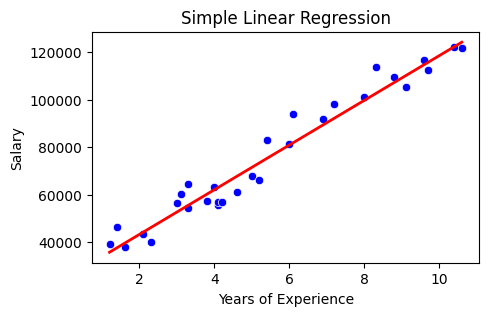

In [52]:
plt.figure(figsize=(5,3))
sns.scatterplot(x="YearsExperience",
                y="Salary",
                data= dataset,
                color="blue"
)

plt.plot(
    dataset["YearsExperience"],
    model.predict(x),
    color="red",
    linewidth=2
)
plt.title("Simple Linear Regression")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()


In [54]:
print("\nRegression Equation")
print(f"Salary = {model.intercept_:.2f}+({model.coef_[0]:.2f} * YearsExperience)")


Regression Equation
Salary = 24380.20+(9423.82 * YearsExperience)
